In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import skimpy as sk
from imblearn.over_sampling import SMOTE
import plotly.express as pl
from scipy import stats
from scipy.stats import uniform, randint
from datetime import datetime
import time

#Models to use
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import GradientBoostingClassifier

#Utils
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold


#For More Metrics Visualization
from sklearn.metrics import(
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    precision_recall_curve,
    auc,
    average_precision_score
)
from statsmodels.stats.contingency_tables import mcnemar


#Model Export
import joblib

In [47]:
df = pd.read_csv("ph_financial_training_set.csv")
df

,transaction_id,date,amount,location,category,fraud_type,is_fraud
0,T100000,2023-08-22,343.78,6,7,NaN,False
1,T100001,2023-08-04,419.65,7,2,NaN,False
2,T100002,2023-05-12,2773.86,2,3,NaN,False
3,T100003,2023-10-10,1666.22,5,2,NaN,False
4,T100004,2023-09-24,24.43,7,7,NaN,False
...,...,...,...,...,...,...,...
4999995,T5099995,2023-11-17,10.87,7,5,NaN,False
4999996,T5099996,2023-09-23,181.40,5,1,NaN,False
4999997,T5099997,2023-11-18,12.54,3,7,NaN,False
4999998,T5099998,2023-03-25,376.29,1,4,NaN,False


In [48]:
#just checking if its empty
df.isnull().sum()

,0
transaction_id,0
date,0
amount,0
location,0
category,0
fraud_type,4820447
is_fraud,0


In [49]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")

#For Labeling Fraud Type and is_fraud

def rule0_overpricing(transactions):  # Label 0
    # Using 'category' instead of 'merchant_category'
    median_per_category = transactions.groupby('category')['amount'].transform('median')
    flag = transactions['amount'] > 1.5 * median_per_category
    return flag

def rule1_duplicate(transactions):  # Label 1
    # Using 'category' as payee and 'location' as description substitute
    transactions = transactions.sort_values(by=['category', 'date'])
    # We are going to check consecutive transactions per category
    transactions['prev_date'] = transactions.groupby('category')['date'].shift(1)
    transactions['prev_location'] = transactions.groupby('category')['location'].shift(1)
    # Time difference in days
    transactions['days_diff'] = (transactions['date'] - transactions['prev_date']).dt.days
    # Check if same location and within 7 days
    flag = (transactions['days_diff'] <= 7) & (transactions['location'] == transactions['prev_location'])
    return flag

# Apply Rule 0 and Rule 1 to your main dataframe
df['is_fraud_0'] = rule0_overpricing(df)
df['is_fraud_1'] = rule1_duplicate(df)

# Rule 2: Inefficient Capital Deployment (Label 2)
# Calculate spent budget per category from your transactions
category_spending = df.groupby('category')['amount'].sum().reset_index()
category_spending.columns = ['category', 'spent_budget']

category_mapping = {
    1: 'education',
    2: 'infrastructure',
    3: 'health',
    4: 'local_gov',
    5: 'transportation',
    6: 'national_defense',
    7: 'social_welfare'
}

allocated_budgets = {
    'education': 977600000,
    'infrastructure': 900000000,
    'health': 297600000,
    'local_gov': 278400000,
    'transportation': 123700000,
    'national_defense': 315100000,
    'social_welfare': 217500000
}

# Create analysis table
analysis_df = category_spending.copy()
analysis_df['category_name'] = analysis_df['category'].map(category_mapping)
analysis_df['allocated_budget'] = analysis_df['category_name'].map(allocated_budgets)
analysis_df['utilization_pct'] = (analysis_df['spent_budget'] / analysis_df['allocated_budget']) * 100
analysis_df['inefficient_deployment'] = analysis_df['utilization_pct'] < 70

inefficient_categories = analysis_df[analysis_df['inefficient_deployment']]['category'].tolist()

# Apply Rule 2 to main dataframe
df['is_fraud_2'] = df['category'].isin(inefficient_categories)

# Combine all fraud labels into final fraud_type column
def assign_fraud_label(row):
    if row['is_fraud_2']:
        return 2  # Inefficient Capital Deployment
    elif row['is_fraud_1']:
        return 1  # Duplicate disbursements
    elif row['is_fraud_0']:
        return 0  # Overpricing

df['fraud_label'] = df.apply(assign_fraud_label, axis=1)
df['is_fraud'] = df['fraud_label'] >= 0  # Mark as fraud if any label is 0, 1 or 2

# Map labels to fraud_type names
fraud_type_mapping = {
    0: 'overpricing',
    1: 'duplicate_disbursement',
    2: 'inefficient_capital_deployment'
}

df['fraud_type'] = df['fraud_label'].map(fraud_type_mapping)

# Clean up temporary columns
df = df.drop(['is_fraud_0', 'is_fraud_1', 'is_fraud_2'], axis=1)

print("Fraud labeling completed:")
print(df['fraud_type'].value_counts())
print("\nSample of flagged transactions:")
print(df[df['is_fraud']].head()[['transaction_id', 'amount', 'category', 'fraud_type']])

Fraud labeling completed:
fraud_type
overpricing                       1432425
inefficient_capital_deployment    1248535
duplicate_disbursement             468092
Name: count, dtype: int64

Sample of flagged transactions:
  transaction_id   amount  category                      fraud_type
0        T100000   343.78         7                     overpricing
1        T100001   419.65         2  inefficient_capital_deployment
2        T100002  2773.86         3                     overpricing
3        T100003  1666.22         2  inefficient_capital_deployment
9        T100009   203.05         1  inefficient_capital_deployment


In [50]:
imputer = SimpleImputer()
df["fraud_label"] = imputer.fit_transform(df[["fraud_label"]])
df["is_fraud"] = imputer.fit_transform(df[["is_fraud"]])

df["fraud_label"] = round(df["fraud_label"])
df = df.drop(columns=["fraud_type"], axis=1)

In [51]:
df.to_csv("final_ph_financial_training_set.csv", index=False)

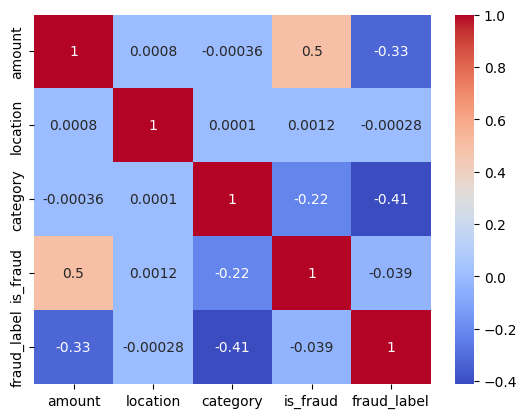

In [52]:
#Data Visualization
#Correlation Matrix
corr = df[["amount", "location", "category", "is_fraud", "fraud_label"]].corr()
sns.heatmap(corr, cmap="coolwarm", annot=True)
#plt.savefig("Correlation Matrix.png")
plt.show()

In [53]:
sk.skim(df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                 Data Types                                                                │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                         │
│ ┃ Dataframe         ┃ Values  ┃ ┃ Column Type ┃ Count ┃                                                         │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                         │
│ │ Number of rows    │ 5000000 │ │ float64     │ 3     │                                                         │
│ │ Number of columns │ 7       │ │ int64       │ 2     │                                                         │
│ └───────────────────┴─────────┘ │ datetime64  │ 1     │                                                         │
│                                 │ string      │ 1     │                                                         │
│                                 └─────────────┴───────┘                                                         │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━━━┓  │
│ ┃ column         ┃ NA  ┃ NA %   ┃ mean     ┃ sd       ┃ p0     ┃ p25     ┃ p50    ┃ p75    ┃ p100  ┃ hist    ┃  │
│ ┡━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━━━┩  │
│ │ amount         │   0 │      0 │    358.9 │    469.9 │   0.01 │   26.57 │  138.7 │  503.9 │  3521 │   █▁▁   │  │
│ │ location       │   0 │      0 │      3.5 │    2.291 │      0 │       2 │      4 │      6 │     7 │ █▄▄▄▄█  │  │
│ │ category       │   0 │      0 │      3.5 │    2.291 │      0 │       1 │      4 │      5 │     7 │ █▄▄▄▄█  │  │
│ │ is_fraud       │   0 │      0 │   0.6298 │   0.4829 │      0 │       0 │      1 │      1 │     1 │ ▅    █  │  │
│ │ fraud_label    │   0 │      0 │   0.9632 │   0.7313 │      0 │       0 │      1 │      1 │     2 │ ▅  █ ▄  │  │
│ └────────────────┴─────┴────────┴──────────┴──────────┴────────┴─────────┴────────┴────────┴───────┴─────────┘  │
│                                                    datetime                                                     │
│ ┏━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓  │
│ ┃ column         ┃ NA     ┃ NA %       ┃ first                 ┃ last                  ┃ frequency           ┃  │
│ ┡━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩  │
│ │ date           │      0 │          0 │      2023-01-01       │      2024-01-01       │ None                │  │
│ └────────────────┴────────┴────────────┴───────────────────────┴───────────────────────┴─────────────────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━┓  │
│ ┃             ┃    ┃      ┃          ┃          ┃         ┃         ┃ chars per   ┃ words per   ┃ total      ┃  │
│ ┃ column      ┃ NA ┃ NA % ┃ shortest ┃ longest  ┃ min     ┃ max     ┃ row         ┃ row         ┃ words      ┃  │
│ ┡━━━━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━┩  │
│ │ transaction │  0 │    0 │ T100000  │ T1000000 │ T100000 │ T999999 │        7.82 │           1 │    5000000 │  │
│ │ _id         │    │      │          │          │         │         │             │             │            │  │
│ └─────────────┴────┴──────┴──────────┴──────────┴─────────┴─────────┴─────────────┴─────────────┴────────────┘  │
╰────────────────────────────────────────────────────── 

In [54]:
#Measuring fraud_label and is_fraud
df["is_fraud"].value_counts()

,count
is_fraud,
1.0,3149052
0.0,1850948


In [55]:
df["fraud_label"].value_counts()

,count
fraud_label,
1.0,2319040
0.0,1432425
2.0,1248535


In [56]:
param_distributions = {
    "LogisticRegression": {
        'C': uniform(0.001, 1000),  # Wider range
        'penalty': ['l1', 'l2', 'elasticnet'],
        'solver': ['saga'],
        'class_weight': [None, 'balanced'],
        'l1_ratio': uniform(0, 1)
    },
    "RandomForestClassifier": {
        'n_estimators': randint(50, 500),
        'max_depth': [None] + list(range(5, 50, 5)),
        'min_samples_split': randint(2, 20),
        'min_samples_leaf': randint(1, 10),
        'max_features': ['sqrt', 'log2', None],
        'bootstrap': [True, False],
        'class_weight': [None, 'balanced', 'balanced_subsample']
    },
    "DecisionTreeClassifier": {
        'max_depth': [None] + list(range(5, 50, 5)),
        'min_samples_split': randint(2, 20),
        'min_samples_leaf': randint(1, 10),
        'max_features': ['sqrt', 'log2', None],
        'criterion': ['gini', 'entropy'],
        'class_weight': [None, 'balanced']
    },
    "XGBClassifier": {
        'n_estimators': randint(50, 500),
        'max_depth': randint(3, 15),
        'learning_rate': uniform(0.01, 0.3),
        'subsample': uniform(0.6, 0.4),  # 0.6 to 1.0
        'colsample_bytree': uniform(0.6, 0.4),
        'gamma': uniform(0, 5),
        'reg_alpha': uniform(0, 10),
        'reg_lambda': uniform(0, 10),
        'scale_pos_weight': [1, 2, 5, 10]  # Important for imbalanced fraud data
    },
    "CatBoostClassifier": {
        'iterations': randint(50, 500),
        'depth': randint(4, 12),
        'learning_rate': uniform(0.01, 0.3),
        'l2_leaf_reg': uniform(1, 10),
        'border_count': [32, 64, 128, 254],
        'random_strength': uniform(0, 10),
        'scale_pos_weight': [1, 2, 5, 10]
    },
    "AdaBoostClassifier": {
        'n_estimators': randint(50, 300),
        'learning_rate': uniform(0.01, 1.0),
        'algorithm': ['SAMME', 'SAMME.R']
    },
    "BaggingClassifier": {
        'n_estimators': randint(10, 200),
        'max_samples': uniform(0.1, 0.9),
        'max_features': uniform(0.1, 0.9),
        'bootstrap': [True, False],
        'bootstrap_features': [True, False]
    },
}

#Parameter Model Classes
model_classes = {
    "LogisticRegression": LogisticRegression(random_state=42, max_iter=1000),
    "RandomForestClassifier": RandomForestClassifier(random_state=42),
    "DecisionTreeClassifier": DecisionTreeClassifier(random_state=42),
    "XGBClassifier": XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0),
    "CatBoostClassifier": CatBoostClassifier(random_state=42, verbose=False),
    "AdaBoostClassifier": AdaBoostClassifier(random_state=42),
    "BaggingClassifier": BaggingClassifier(random_state=42),
}

In [57]:
X = df.drop(columns=["date", "transaction_id", "is_fraud"], axis=1)
y = df["is_fraud"]

In [58]:
X_train, X_test, Y_train, Y_test = train_test_split(X, y, stratify=y, test_size=0.8, random_state=42)

In [59]:
#Starting Grid Search (abandoned)
models_to_tune = ['LogisticRegression', 'RandomForestClassifier', 'XGBClassifier', 'DecisionTreeClassifier', 'LogisticRegression', 'CatBoostClassifier', 'AdaBoostClassifier']

best_models = {}
search_results = []

n_iter = 50  # Number of parameter combinations to try
cv = 3       # Cross-validation folds
scoring = 'f1'  # Scoring metric
n_jobs = -1  # Use all available cores
random_state = 42

for model_name in models_to_tune:
  start_time = time.time()
  print(f"\n Tuning {model_name}...")

  # Initialize model
  model = model_classes[model_name]

  # Perform RandomizedSearchCV
  random_search = RandomizedSearchCV(
      estimator=model,
      param_distributions=param_distributions[model_name],
      n_iter=n_iter,
      cv=cv,
      scoring=scoring,
      n_jobs=n_jobs,
      random_state=random_state,
      verbose=1,
      return_train_score=True,
      error_score='raise'
  )

  # Fit the model
  random_search.fit(X_train, Y_train)

  # Calculate training time
  training_time = time.time() - start_time

  # Store results
  best_models[model_name] = {
      'best_estimator': random_search.best_estimator_,
      'best_params': random_search.best_params_,
      'best_score': random_search.best_score_,
      'training_time': training_time,
      'cv_results': random_search.cv_results_
  }

  search_results.append({
      'Model': model_name,
      'Best_Score': random_search.best_score_,
      'Training_Time_Minutes': training_time / 60,
      'Best_Params': random_search.best_params_
  })

  print(f"Best {scoring} score: {random_search.best_score_:.4f}")
  print(f"Training time: {training_time/60:.2f} minutes")
  print(f"Best parameters: {random_search.best_params_}")


 Tuning LogisticRegression...
Fitting 3 folds for each of 50 candidates, totalling 150 fits


KeyboardInterrupt: 

In [ ]:
#Results (abandoned)
results_df = pd.DataFrame(search_results).sort_values('Best_Score', ascending=False)

print(results_df.round(4))

In [ ]:
#Evaluating The best model on the test set (abandoned and will be )
evaluation_results = []

for model_name, model_info in best_models.items():
    best_estimator = model_info['best_estimator']

    # Predictions
    y_pred = best_estimator.predict(X_test)
    y_pred_proba = best_estimator.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(Y_test, y_pred)
    precision = precision_score(Y_test, y_pred)
    recall = recall_score(Y_test, y_pred)
    f1 = f1_score(Y_test, y_pred)
    roc_auc = roc_auc_score(Y_test, y_pred_proba)

    evaluation_results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1_Score': f1,
        'ROC_AUC': roc_auc,
        'Training_Score': model_info['best_score']
    })

    print(f"\n📊 {model_name} Test Results:")
    print(f"   Accuracy:  {accuracy:.4f}")
    print(f"   Precision: {precision:.4f}")
    print(f"   Recall:    {recall:.4f}")
    print(f"   F1-Score:  {f1:.4f}")
    print(f"   ROC-AUC:   {roc_auc:.4f}")

In [60]:
model = RandomForestClassifier(
    n_estimators=200,              # enough trees for stability
    max_depth=15,                 # prevents overfitting on noisy features
    min_samples_split=10,          # avoids tiny branches
    min_samples_leaf=5,           # keeps leaves from becoming too small
    max_features='sqrt',          # typical for classification
    bootstrap=True,               # keeps trees diverse
    class_weight='balanced_subsample',  # compensates for any imbalance
    random_state=42,
    n_jobs=-1
)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", model) #We wait
])

pipe.fit(X_train, Y_train)

y_pred = pipe.predict(X_test)

In [61]:
y_pred_proba = pipe.predict_proba(X_test)[:, 1]

In [62]:
#Metrics for accuracy
accuracy = accuracy_score(Y_test, y_pred)
precision = precision_score(Y_test, y_pred)
recall = recall_score(Y_test, y_pred)
f1 = f1_score(Y_test, y_pred)
roc_auc = roc_auc_score(Y_test, y_pred_proba)




print(f"\n{model} Test Results:")
print(f"   Accuracy:  {accuracy:.4f}")
print(f"   Precision: {precision:.4f}")
print(f"   Recall:    {recall:.4f}")
print(f"   F1-Score:  {f1:.4f}")
print(f"   ROC-AUC:   {roc_auc:.4f}")



RandomForestClassifier(class_weight='balanced_subsample', max_depth=15,
                       min_samples_leaf=5, min_samples_split=10,
                       n_estimators=200, n_jobs=-1, random_state=42) Test Results:
   Accuracy:  0.9473
   Precision: 1.0000
   Recall:    0.9163
   F1-Score:  0.9563
   ROC-AUC:   0.9581


In [63]:
#Applying McNemar's Test on our Candidate model to statistically prove it
gb_model = GradientBoostingClassifier(
    n_estimators=300,           # enough trees for smooth learning
    learning_rate=0.05,         # smaller = slower but better generalization
    max_depth=5,                # deep enough to capture interactions
    min_samples_split=5,
    min_samples_leaf=2,
    subsample=0.8,
    max_features='sqrt',
    random_state=42
)

gb_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", gb_model)
])

gb_pipe.fit(X_train, Y_train)

gb_y_pred = gb_pipe.predict(X_test)
gb_y_pred_proba = gb_pipe.predict_proba(X_test)[:, 1]


both_correct = ((y_pred == Y_test) & (gb_y_pred == Y_test)).sum()
rf_only = ((y_pred == Y_test) & (gb_y_pred != Y_test)).sum()
gb_only = ((gb_y_pred == Y_test) & (y_pred != Y_test)).sum()
both_wrong = ((y_pred != Y_test) & (gb_y_pred != Y_test)).sum()

table = [[both_correct, rf_only],
         [gb_only, both_wrong]]

# Run McNemar’s test
result = mcnemar(table, exact=True)
print(f"Statistic={result.statistic}, p-value={result.pvalue:.5f}")

Statistic=14.0, p-value=0.85554


In [66]:
# Statistical Testing For Two Models
# DeLong implementation

def compute_midrank(x):
    """Computes midranks for an array x"""
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T = np.zeros(N, dtype=float)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1)
        i = j
    T2 = np.empty(N, dtype=float)
    T2[J] = T + 1
    return T2

def fastDeLong(predictions_sorted_transposed, label_1_count):
    """Fast implementation of DeLong's method for computing AUC variance"""
    m = label_1_count
    n = predictions_sorted_transposed.shape[1] - m
    positive_examples = predictions_sorted_transposed[:, :m]
    negative_examples = predictions_sorted_transposed[:, m:]
    k = predictions_sorted_transposed.shape[0]

    tx = np.empty((k, m), dtype=float)
    ty = np.empty((k, n), dtype=float)
    for r in range(k):
        tx[r, :] = compute_midrank(positive_examples[r, :])
        ty[r, :] = compute_midrank(negative_examples[r, :])

    aucs = tx.mean(axis=1) / n - ty.mean(axis=1) / m
    v01 = (tx - tx.mean(axis=1, keepdims=True)) / n
    v10 = (ty - ty.mean(axis=1, keepdims=True)) / m
    s01 = np.cov(v01)
    s10 = np.cov(v10)
    return aucs, s01 / m + s10 / n

def calc_auc(y_true, y_scores):
    pos = y_scores[y_true == 1]
    neg = y_scores[y_true == 0]
    return (np.sum(pos[:, None] > neg) + 0.5 * np.sum(pos[:, None] == neg)) / (len(pos) * len(neg))

def delong_roc_test(y_true, preds_A, preds_B):
    """Performs DeLong test between two AUCs"""
    order = np.argsort(-np.vstack((preds_A, preds_B)))
    preds_sorted_transposed = np.vstack((preds_A, preds_B))[:, order[0]]
    label_1_count = np.sum(y_true)
    aucs, delong_cov = fastDeLong(preds_sorted_transposed, int(label_1_count))
    diff = aucs[0] - aucs[1]
    var = delong_cov[0, 0] + delong_cov[1, 1] - 2 * delong_cov[0, 1]
    z_stat = diff / np.sqrt(var)
    p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))
    return p_value


p_value = delong_roc_test(Y_test.values, y_pred_proba, gb_y_pred_proba)
print(f"DeLong p-value: {p_value:.5f}")

DeLong p-value: 1.00000


In [70]:
#Precision Recall Curve for Final Used Model
precision, recall, thresholds = precision_recall_curve(Y_test, y_pred_proba)

auc_pr_score_auc = auc(recall, precision)

# Using average_precision_score()
auc_pr_score_ap = average_precision_score(Y_test, y_pred_proba)

print(f"AUC-PR (using auc): {auc_pr_score_auc:.4f}")
print(f"Average Precision Score: {auc_pr_score_ap:.4f}")

AUC-PR (using auc): 0.9817
Average Precision Score: 0.9817


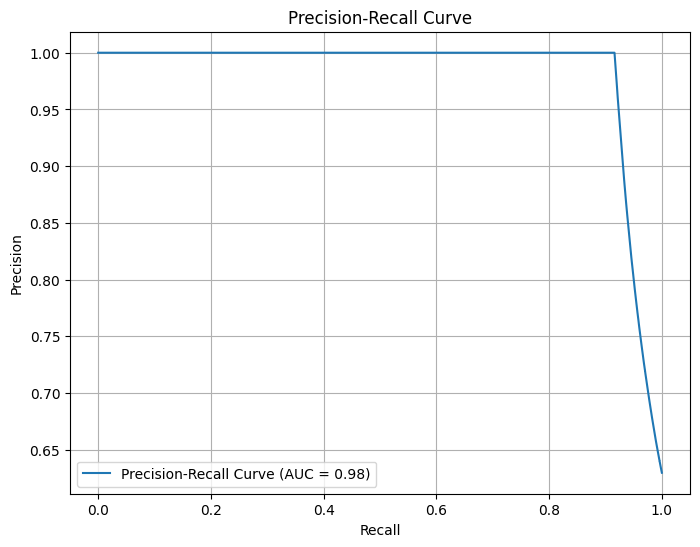

In [71]:
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AUC = {auc_pr_score_ap:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.savefig("Precision-Recall Curve.png")
plt.show()

In [73]:
#Exporting The ML Model
joblib.dump(pipe, "ClassifierModel.pkl")

['ClassifierModel.pkl']